In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
customer_df = pd.read_csv(r"D:\git\python-data-analysis-lab\datasets\customers_master_dataset.csv")
customer_df

,customer_id,customer_name,city,customer_segment,age
0,C001,Customer_1,Chennai,Premium,21
1,C002,Customer_2,Chennai,Regular,35
2,C003,Customer_3,Pune,Premium,26
3,C004,Customer_4,Chennai,New,54
4,C005,Customer_5,Mumbai,New,47
...,...,...,...,...,...
195,C196,Customer_196,Pune,Premium,29
196,C197,Customer_197,Mumbai,Premium,35
197,C198,Customer_198,Bangalore,New,24
198,C199,Customer_199,Bangalore,Regular,60


In [57]:
transaction_df = pd.read_csv(r"D:\git\python-data-analysis-lab\datasets\transactions_dataset_2000_rows.csv")
transaction_df

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
0,1,C127,2026-02-07,Electronics,4,32179,UPI,Failed
1,2,C057,2026-05-13,Furniture,2,91414,UPI,Cancelled
2,3,C064,2026-02-04,Furniture,1,60029,Cash,Failed
3,4,C157,2026-05-21,Furniture,5,56133,Card,Failed
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed
...,...,...,...,...,...,...,...,...
1995,1996,C057,2026-03-25,Grocery,2,2568,UPI,Cancelled
1996,1997,C074,2026-05-31,Furniture,5,60577,Cash,Cancelled
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed
1998,1999,C089,2026-04-29,Furniture,4,20093,Card,Cancelled


In [58]:
customer_df.isna().sum()

customer_id         0
customer_name       0
city                0
customer_segment    0
age                 0
dtype: int64

In [59]:
transaction_df.isna().sum()

transaction_id      0
customer_id         0
transaction_date    0
product_category    0
quantity            0
sales_amount        0
payment_method      0
status              0
dtype: int64

In [60]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       200 non-null    object
 1   customer_name     200 non-null    object
 2   city              200 non-null    object
 3   customer_segment  200 non-null    object
 4   age               200 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 7.9+ KB


In [61]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    2000 non-null   int64 
 1   customer_id       2000 non-null   object
 2   transaction_date  2000 non-null   object
 3   product_category  2000 non-null   object
 4   quantity          2000 non-null   int64 
 5   sales_amount      2000 non-null   int64 
 6   payment_method    2000 non-null   object
 7   status            2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [62]:
# Question 1 :Using transactions_df, find all Completed transactions where:
# sales_amount > 50,000
# Return only:

# transaction_id
# customer_id
# transaction_date
# product_category
# sales_amount
# payment_method

# Sort by:
# sales_amount → highest to lowest

In [63]:
comp_trans = transaction_df[(transaction_df['status']=='Completed') & (transaction_df['sales_amount'] > 50000)]
comp_trans= comp_trans[['transaction_id','customer_id','transaction_date','product_category','sales_amount','payment_method']].sort_values(by='sales_amount', ascending= False)
comp_trans

,transaction_id,customer_id,transaction_date,product_category,sales_amount,payment_method
370,371,C145,2026-02-26,Fashion,99953,UPI
1524,1525,C186,2026-02-21,Accessories,99944,Card
221,222,C103,2026-04-05,Accessories,99901,UPI
60,61,C170,2026-05-21,Electronics,99880,Net Banking
80,81,C112,2026-06-12,Electronics,99863,Net Banking
...,...,...,...,...,...,...
264,265,C002,2026-03-02,Furniture,50475,Cash
531,532,C110,2026-01-02,Electronics,50442,Card
1672,1673,C084,2026-03-02,Accessories,50381,UPI
444,445,C128,2026-06-24,Furniture,50365,Card


In [64]:
# Question 2
# Using transaction_df, find the total revenue and number of transactions for each product category, considering only Completed transactions.

# Expected output:
# product_category | total_revenue | total_transactions

# Sort by:
# total_revenue → highest to lowest

In [65]:
comp_trans= transaction_df[transaction_df['status']=='Completed']
result = (
    comp_trans.groupby('product_category')
    .agg(total_revenue=('sales_amount','sum'),
         total_transaction = ('transaction_id','count'))
    .sort_values(by='total_revenue', ascending=False)
    .reset_index()
)
result

,product_category,total_revenue,total_transaction
0,Fashion,12982577,258
1,Furniture,12715718,259
2,Grocery,12301323,244
3,Accessories,11015343,227
4,Electronics,10538585,213


In [66]:
comp_trans.groupby('product_category')[['sales_amount']].sum().sort_values(by='sales_amount', ascending=False)

,sales_amount
product_category,
Fashion,12982577
Furniture,12715718
Grocery,12301323
Accessories,11015343
Electronics,10538585


In [67]:
# Question 3 — Customer + Transaction

# Find the top 10 customers by total spending.

# First, consider only:status = 'Completed'

# Expected output:
# customer_id | customer_name | city | total_spent | total_transactions

# Sort:
# total_spent → highest to lowest

In [69]:
trans_df= transaction_df[transaction_df['status']=='Completed']

In [ ]:
cust_trans=pd.merge(customer_df, trans_df, on ='customer_id', how ='left')
cust_trans

,customer_id,customer_name,city,customer_segment,age,transaction_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
0,C001,Customer_1,Chennai,Premium,21,49,2026-06-26,Accessories,4,59248,Net Banking,Completed
1,C001,Customer_1,Chennai,Premium,21,419,2026-03-04,Electronics,1,1810,Net Banking,Completed
2,C001,Customer_1,Chennai,Premium,21,548,2026-01-23,Electronics,1,88232,Net Banking,Completed
3,C001,Customer_1,Chennai,Premium,21,1297,2026-02-28,Furniture,2,91061,Card,Completed
4,C001,Customer_1,Chennai,Premium,21,1419,2026-06-12,Fashion,3,2379,UPI,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...
1196,C199,Customer_199,Bangalore,Regular,60,1868,2026-06-03,Furniture,4,64317,Card,Completed
1197,C200,Customer_200,Hyderabad,Premium,44,504,2026-01-08,Grocery,5,74737,Card,Completed
1198,C200,Customer_200,Hyderabad,Premium,44,578,2026-05-29,Grocery,2,90877,Card,Completed
1199,C200,Customer_200,Hyderabad,Premium,44,932,2026-01-16,Furniture,1,36544,Net Banking,Completed


In [77]:

cust_trans=cust_trans[['customer_id', 'customer_name', 'city','sales_amount','transaction_id']]
result =( 
         cust_trans.groupby(['customer_id','customer_name','city'])
         .agg(total_spent = ("sales_amount",'sum'),
              total_transaction = ('transaction_id','count'))
         .sort_values(by='total_spent', ascending=False)
         .reset_index() 
         .head(10)      
)
result

,customer_id,customer_name,city,total_spent,total_transaction
0,C102,Customer_102,Bangalore,751310,13
1,C095,Customer_95,Mumbai,747979,13
2,C148,Customer_148,Hyderabad,716424,11
3,C096,Customer_96,Mumbai,669504,12
4,C176,Customer_176,Delhi,586709,11
5,C009,Customer_9,Pune,577009,9
6,C152,Customer_152,Chennai,570156,9
7,C082,Customer_82,Chennai,567187,10
8,C145,Customer_145,Hyderabad,566460,9
9,C052,Customer_52,Chennai,554292,11


In [78]:
# Question 4 — Customer Spending by City
# Using both customer_df and transaction_df, find the top 5 cities by total completed sales.

# Only consider:status = 'Completed'

# Expected output:
# city | total_customers | total_transactions | total_sales | avg_transaction_value

# Sort by:
# total_sales → highest to lowest

In [80]:
trans_df = transaction_df[transaction_df['status']=='Completed']

In [83]:
cust_trans = pd.merge(customer_df, trans_df, on= 'customer_id', how ='inner')
cust_trans

,customer_id,customer_name,city,customer_segment,age,transaction_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
0,C001,Customer_1,Chennai,Premium,21,49,2026-06-26,Accessories,4,59248,Net Banking,Completed
1,C001,Customer_1,Chennai,Premium,21,419,2026-03-04,Electronics,1,1810,Net Banking,Completed
2,C001,Customer_1,Chennai,Premium,21,548,2026-01-23,Electronics,1,88232,Net Banking,Completed
3,C001,Customer_1,Chennai,Premium,21,1297,2026-02-28,Furniture,2,91061,Card,Completed
4,C001,Customer_1,Chennai,Premium,21,1419,2026-06-12,Fashion,3,2379,UPI,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...
1196,C199,Customer_199,Bangalore,Regular,60,1868,2026-06-03,Furniture,4,64317,Card,Completed
1197,C200,Customer_200,Hyderabad,Premium,44,504,2026-01-08,Grocery,5,74737,Card,Completed
1198,C200,Customer_200,Hyderabad,Premium,44,578,2026-05-29,Grocery,2,90877,Card,Completed
1199,C200,Customer_200,Hyderabad,Premium,44,932,2026-01-16,Furniture,1,36544,Net Banking,Completed


In [87]:
result = (
    cust_trans.groupby('city')
    .agg(total_transactions=('transaction_id','count'),
         total_sales =('sales_amount','sum'),
         avg_transaction_value = ('sales_amount','mean'),
         total_customers = ('customer_id','nunique'))
    .round(2)
    .sort_values(by='total_sales',ascending=False)
    .reset_index()
    
)
result

,city,total_transactions,total_sales,avg_transaction_value,total_customers
0,Mumbai,274,13357878,48751.38,44
1,Hyderabad,228,11814105,51816.25,36
2,Chennai,194,9542878,49190.09,32
3,Pune,183,9266178,50634.85,34
4,Delhi,167,8091333,48451.10,28
5,Bangalore,155,7481174,48265.64,26


In [ ]:
# Using transaction_df, identify duplicate transactions.

# consider a transaction duplicate if the same combination of:

# customer_id
# transaction_date
# sales_amount
# product_category

# appears more than once.

# Step 1
# Find and display the duplicate rows.
# Expected output should contain the complete duplicate records.

# Step 2
# Then find: total number of duplicate rows

In [97]:
x=transaction_df[transaction_df[['customer_id','transaction_date','sales_amount','product_category']].duplicated(keep =False)]
x=len(x)
x

0

In [98]:
# duplicated()
# → show repeated occurrences except the first

# duplicated(keep=False)
# → show ALL rows involved in the duplicate

# customer_id   amount
# 0     C001        500
# 1     C002        700
# 2     C001        500
# 3     C003        900
# 4     C002        700

# Here:

# Row 0 and Row 2 are duplicates
# Row 1 and Row 4 are duplicates

# df.duplicated()

# Output:

# 0    False
# 1    False
# 2     True
# 3    False
# 4     True
# first occurence is alswyas false then if repeated again it shows True

# df.duplicated(keep=false)
# it shows forst occurnce also as True

In [99]:
# Question 5 — Find inactive customers
# Using both customer_df and transaction_df:

# Find customers who have never made a Completed transaction.
# Expected output:
# customer_id | customer_name | city | customer_segment

In [115]:
completed = transaction_df[transaction_df['status']== 'Completed']
completed

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed
5,6,C071,2026-03-15,Grocery,4,10355,Cash,Completed
11,12,C057,2026-05-05,Electronics,3,57325,Net Banking,Completed
13,14,C137,2026-06-01,Accessories,1,51845,UPI,Completed
14,15,C165,2026-04-29,Grocery,4,17986,UPI,Completed
...,...,...,...,...,...,...,...,...
1992,1993,C071,2026-01-12,Accessories,5,88206,Net Banking,Completed
1993,1994,C174,2026-01-02,Furniture,3,35940,Card,Completed
1994,1995,C107,2026-03-10,Furniture,2,36214,Cash,Completed
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed


In [119]:
result = pd.merge(customer_df,completed, on='customer_id',how='left',indicator=True)
result 

,customer_id,customer_name,city,customer_segment,age,transaction_id,transaction_date,product_category,quantity,sales_amount,payment_method,status,_merge
0,C001,Customer_1,Chennai,Premium,21,49,2026-06-26,Accessories,4,59248,Net Banking,Completed,both
1,C001,Customer_1,Chennai,Premium,21,419,2026-03-04,Electronics,1,1810,Net Banking,Completed,both
2,C001,Customer_1,Chennai,Premium,21,548,2026-01-23,Electronics,1,88232,Net Banking,Completed,both
3,C001,Customer_1,Chennai,Premium,21,1297,2026-02-28,Furniture,2,91061,Card,Completed,both
4,C001,Customer_1,Chennai,Premium,21,1419,2026-06-12,Fashion,3,2379,UPI,Completed,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,C199,Customer_199,Bangalore,Regular,60,1868,2026-06-03,Furniture,4,64317,Card,Completed,both
1197,C200,Customer_200,Hyderabad,Premium,44,504,2026-01-08,Grocery,5,74737,Card,Completed,both
1198,C200,Customer_200,Hyderabad,Premium,44,578,2026-05-29,Grocery,2,90877,Card,Completed,both
1199,C200,Customer_200,Hyderabad,Premium,44,932,2026-01-16,Furniture,1,36544,Net Banking,Completed,both


In [121]:
# both       → customer exists in BOTH tables
# left_only  → customer exists ONLY in customer_df

result[result['_merge'] == 'left_only'][['customer_id', 'customer_name', 'city', 'customer_segment']]

,customer_id,customer_name,city,customer_segment


In [122]:
# Question: Customers with NO Failed Transactions

# Using customer_df and transaction_df:
# Find all customers who have never had a Failed transaction.

# Expected output
# customer_id | customer_name | city | customer_segment

In [125]:
failed = transaction_df[transaction_df['status']=='Failed']
failed

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
0,1,C127,2026-02-07,Electronics,4,32179,UPI,Failed
2,3,C064,2026-02-04,Furniture,1,60029,Cash,Failed
3,4,C157,2026-05-21,Furniture,5,56133,Card,Failed
6,7,C082,2026-02-05,Grocery,5,10761,Card,Failed
7,8,C178,2026-02-24,Electronics,2,92791,Net Banking,Failed
...,...,...,...,...,...,...,...,...
1978,1979,C182,2026-02-20,Accessories,5,33995,Net Banking,Failed
1979,1980,C013,2026-01-11,Electronics,4,37124,Net Banking,Failed
1980,1981,C094,2026-06-25,Fashion,1,78755,Cash,Failed
1984,1985,C045,2026-01-25,Grocery,1,70321,Card,Failed


In [127]:
result = pd.merge(customer_df, failed, on='customer_id', how ='left', indicator=True)
result

,customer_id,customer_name,city,customer_segment,age,transaction_id,transaction_date,product_category,quantity,sales_amount,payment_method,status,_merge
0,C001,Customer_1,Chennai,Premium,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,C002,Customer_2,Chennai,Regular,35,11.0,2026-04-10,Furniture,3.0,39339.0,Card,Failed,both
2,C002,Customer_2,Chennai,Regular,35,833.0,2026-03-02,Grocery,5.0,64879.0,Net Banking,Failed,both
3,C002,Customer_2,Chennai,Regular,35,981.0,2026-01-11,Furniture,4.0,5996.0,UPI,Failed,both
4,C003,Customer_3,Pune,Premium,26,229.0,2026-02-04,Fashion,1.0,56682.0,Cash,Failed,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,C199,Customer_199,Bangalore,Regular,60,1209.0,2026-01-22,Electronics,2.0,39722.0,Cash,Failed,both
440,C199,Customer_199,Bangalore,Regular,60,1451.0,2026-06-16,Furniture,1.0,60974.0,Cash,Failed,both
441,C200,Customer_200,Hyderabad,Premium,44,211.0,2026-05-31,Grocery,5.0,84059.0,Card,Failed,both
442,C200,Customer_200,Hyderabad,Premium,44,860.0,2026-04-24,Accessories,2.0,12337.0,UPI,Failed,both


In [129]:
result[result['_merge']=='left_only'][['customer_id', 'customer_name', 'city', 'customer_segment']]

,customer_id,customer_name,city,customer_segment
0,C001,Customer_1,Chennai,Premium
7,C004,Customer_4,Chennai,New
27,C011,Customer_11,Hyderabad,Regular
47,C018,Customer_18,Hyderabad,Premium
70,C029,Customer_29,Hyderabad,New
101,C043,Customer_43,Bangalore,New
139,C061,Customer_61,Mumbai,New
169,C074,Customer_74,Mumbai,Premium
189,C086,Customer_86,Mumbai,Premium
191,C088,Customer_88,Bangalore,New


In [130]:
# Question: Customer purchase summary

# Using both customer_df and transaction_df, find the top 10 customers by total spending.

# But this time, add one more business condition:
# Only consider customers who have made at least 3 Completed transactions.

# Expected output:
# customer_id | customer_name | city | total_transactions | total_spent | avg_transaction_value

In [ ]:
completed = transaction_df[transaction_df['status']== 'Completed'] 
completed

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed
5,6,C071,2026-03-15,Grocery,4,10355,Cash,Completed
11,12,C057,2026-05-05,Electronics,3,57325,Net Banking,Completed
13,14,C137,2026-06-01,Accessories,1,51845,UPI,Completed
14,15,C165,2026-04-29,Grocery,4,17986,UPI,Completed
...,...,...,...,...,...,...,...,...
1992,1993,C071,2026-01-12,Accessories,5,88206,Net Banking,Completed
1993,1994,C174,2026-01-02,Furniture,3,35940,Card,Completed
1994,1995,C107,2026-03-10,Furniture,2,36214,Cash,Completed
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed


In [ ]:
result = pd.merge(customer_df, completed, on='customer_id',how='inner')

result = (
    result.groupby(['customer_id','customer_name','city'])
    .agg(total_transaction = ('transaction_id','count'),
         total_spent = ('sales_amount','sum'),
         avg_transaction_value=('sales_amount','mean'),
         status_count = ('status','count'))
    .query('status_count >= 3')
    .round(2)
    # .query('total_transaction >= 3')
    .sort_values(by='total_spent', ascending=False)
    .head(10)
    .reset_index()
)
result

,customer_id,customer_name,city,total_transaction,total_spent,avg_transaction_value,status_count
0,C102,Customer_102,Bangalore,13,751310,57793.08,13
1,C095,Customer_95,Mumbai,13,747979,57536.85,13
2,C148,Customer_148,Hyderabad,11,716424,65129.45,11
3,C096,Customer_96,Mumbai,12,669504,55792.00,12
4,C176,Customer_176,Delhi,11,586709,53337.18,11
5,C009,Customer_9,Pune,9,577009,64112.11,9
6,C152,Customer_152,Chennai,9,570156,63350.67,9
7,C082,Customer_82,Chennai,10,567187,56718.70,10
8,C145,Customer_145,Hyderabad,9,566460,62940.00,9
9,C052,Customer_52,Chennai,11,554292,50390.18,11


In [150]:
# Question: Customer spending by segment
# Using both customer_df and transaction_df, find the performance of each customer segment.

# Only consider:
# status = 'Completed'

# Expected output:
# customer_segment | total_customers | total_transactions | total_spent | avg_customer_spend

In [161]:
completed = transaction_df[transaction_df['status'] == 'Completed']

In [162]:
result = pd.merge(customer_df, completed, on ='customer_id', how ='inner')
result

,customer_id,customer_name,city,customer_segment,age,transaction_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
0,C001,Customer_1,Chennai,Premium,21,49,2026-06-26,Accessories,4,59248,Net Banking,Completed
1,C001,Customer_1,Chennai,Premium,21,419,2026-03-04,Electronics,1,1810,Net Banking,Completed
2,C001,Customer_1,Chennai,Premium,21,548,2026-01-23,Electronics,1,88232,Net Banking,Completed
3,C001,Customer_1,Chennai,Premium,21,1297,2026-02-28,Furniture,2,91061,Card,Completed
4,C001,Customer_1,Chennai,Premium,21,1419,2026-06-12,Fashion,3,2379,UPI,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...
1196,C199,Customer_199,Bangalore,Regular,60,1868,2026-06-03,Furniture,4,64317,Card,Completed
1197,C200,Customer_200,Hyderabad,Premium,44,504,2026-01-08,Grocery,5,74737,Card,Completed
1198,C200,Customer_200,Hyderabad,Premium,44,578,2026-05-29,Grocery,2,90877,Card,Completed
1199,C200,Customer_200,Hyderabad,Premium,44,932,2026-01-16,Furniture,1,36544,Net Banking,Completed


In [163]:

result = (
    result.groupby('customer_segment')
    .agg( 
         total_customers = ('customer_id','nunique'),
         total_transactions =('transaction_id', 'count'),
         total_spent = ('sales_amount','sum')
         )
)
result

,total_customers,total_transactions,total_spent
customer_segment,,,
New,75,444,21996760
Premium,67,418,20442584
Regular,58,339,17114202


In [165]:

result['avg_customer_spend'] = result['total_spent']/result['total_customers']
result

,total_customers,total_transactions,total_spent,avg_customer_spend
customer_segment,,,,
New,75,444,21996760,293290.133333
Premium,67,418,20442584,305113.194030
Regular,58,339,17114202,295072.448276


In [167]:
result = (
    result
    .round(2)
    .sort_values(by ='total_spent',ascending=False)
    .reset_index()
)
result

,index,customer_segment,total_customers,total_transactions,total_spent,avg_customer_spend
0,0,New,75,444,21996760,293290.13
1,1,Premium,67,418,20442584,305113.19
2,2,Regular,58,339,17114202,295072.45


In [ ]:
# Question: Product Category Performance
# Using transaction_df + customer_df, analyze completed transactions by product category.

# Only consider:
# status = 'Completed'

# Find:
# product_category | total_customers | total_transactions | total_quantity | total_sales | avg_transaction_value
# Sort by:
# total_sales → highest to lowest

In [169]:
completed = transaction_df[transaction_df['status'] == 'Completed']

In [172]:
result = pd.merge(customer_df, completed, on='customer_id', how ='inner')

result = (
    result.groupby('product_category')
    .agg(total_customers =('customer_id','nunique'),
         total_transactions =('transaction_id','count'),
         total_quantity=('quantity','sum'),
         total_sales=('sales_amount','sum'),
         avg_transaction_value=('sales_amount','mean'))
    .round(2)
    .sort_values(by='total_sales', ascending =False)
    .reset_index()
)
result

,product_category,total_customers,total_transactions,total_quantity,total_sales,avg_transaction_value
0,Fashion,138,258,736,12982577,50320.07
1,Furniture,146,259,759,12715718,49095.44
2,Grocery,146,244,757,12301323,50415.26
3,Accessories,132,227,668,11015343,48525.74
4,Electronics,128,213,682,10538585,49476.92


In [173]:
# Next question — let's introduce transform()

# Find each customer's total spending and compare it with the average customer spending.

# Expected output:
# customer_id | total_spent | average_customer_spend | above_average

# Only use:
# status = Completed

# For above_average:
# True  → customer's spending > average customer spending
# False → customer's spending <= average customer spending

In [174]:
completed = transaction_df[transaction_df['status'] == 'Completed']

In [177]:
result = (
    completed.groupby('customer_id')
    .agg(total_spent = ('sales_amount','sum'),
         average_customer_spend=('sales_amount','mean'))
    .round(2)
    .reset_index()
)
result

,customer_id,total_spent,average_customer_spend
0,C001,348537,49791.00
1,C002,204328,51082.00
2,C003,67837,33918.50
3,C004,326311,46615.86
4,C005,257721,51544.20
...,...,...,...
195,C196,339461,56576.83
196,C197,323446,46206.57
197,C198,351943,43992.88
198,C199,64317,64317.00


In [184]:
result = (
    completed
    .groupby('customer_id')
    .agg(total_spent=('sales_amount', 'sum'))
    .reset_index()
)
result['average_customer_spend'] = result['total_spent'].mean()
result


,customer_id,total_spent,average_customer_spend
0,C001,348537,297767.73
1,C002,204328,297767.73
2,C003,67837,297767.73
3,C004,326311,297767.73
4,C005,257721,297767.73
...,...,...,...
195,C196,339461,297767.73
196,C197,323446,297767.73
197,C198,351943,297767.73
198,C199,64317,297767.73


In [183]:
result['above_average'] = (
    result['total_spent'] > result['average_customer_spend']
)
result

,customer_id,total_spent,average_customer_spend,above_average
0,C001,348537,297767.73,True
1,C002,204328,297767.73,False
2,C003,67837,297767.73,False
3,C004,326311,297767.73,True
4,C005,257721,297767.73,False
...,...,...,...,...
195,C196,339461,297767.73,True
196,C197,323446,297767.73,True
197,C198,351943,297767.73,True
198,C199,64317,297767.73,False


In [185]:
# Question — Rank customers within each city

# Using transaction_df + customer_df:

# Consider only Completed transactions.
# Calculate each customer's total spending.
# Rank customers within their city based on total spending.
# Find the top 3 customers from each city.

# Expected output:
# customer_id | customer_name | city | total_spent | rank

In [199]:
completed = transaction_df[transaction_df['status']== 'Completed']


In [200]:
result = pd.merge(customer_df, completed, on='customer_id', how='inner')
result = (
    result.groupby(['customer_id','customer_name','city'])
    .agg(total_spent =('sales_amount', 'sum'))
    .reset_index()
)
result

,customer_id,customer_name,city,total_spent
0,C001,Customer_1,Chennai,348537
1,C002,Customer_2,Chennai,204328
2,C003,Customer_3,Pune,67837
3,C004,Customer_4,Chennai,326311
4,C005,Customer_5,Mumbai,257721
...,...,...,...,...
195,C196,Customer_196,Pune,339461
196,C197,Customer_197,Mumbai,323446
197,C198,Customer_198,Bangalore,351943
198,C199,Customer_199,Bangalore,64317


In [201]:
result['rank']=(
    result.groupby('city')['total_spent']
    .rank(method='first',ascending=False)
)
result

,customer_id,customer_name,city,total_spent,rank
0,C001,Customer_1,Chennai,348537,10.0
1,C002,Customer_2,Chennai,204328,25.0
2,C003,Customer_3,Pune,67837,30.0
3,C004,Customer_4,Chennai,326311,14.0
4,C005,Customer_5,Mumbai,257721,30.0
...,...,...,...,...,...
195,C196,Customer_196,Pune,339461,13.0
196,C197,Customer_197,Mumbai,323446,18.0
197,C198,Customer_198,Bangalore,351943,8.0
198,C199,Customer_199,Bangalore,64317,24.0


In [203]:
result =(
    result[result['rank']<=3]
    [['customer_id','customer_name','city','total_spent','rank']]
        .sort_values(by=['city','rank'],ascending=True)
    
)
result

,customer_id,customer_name,city,total_spent,rank
101,C102,Customer_102,Bangalore,751310,1.0
158,C159,Customer_159,Bangalore,527203,2.0
72,C073,Customer_73,Bangalore,489919,3.0
151,C152,Customer_152,Chennai,570156,1.0
81,C082,Customer_82,Chennai,567187,2.0
51,C052,Customer_52,Chennai,554292,3.0
175,C176,Customer_176,Delhi,586709,1.0
186,C187,Customer_187,Delhi,551927,2.0
157,C158,Customer_158,Delhi,532465,3.0
147,C148,Customer_148,Hyderabad,716424,1.0


In [204]:
customer_df

,customer_id,customer_name,city,customer_segment,age
0,C001,Customer_1,Chennai,Premium,21
1,C002,Customer_2,Chennai,Regular,35
2,C003,Customer_3,Pune,Premium,26
3,C004,Customer_4,Chennai,New,54
4,C005,Customer_5,Mumbai,New,47
...,...,...,...,...,...
195,C196,Customer_196,Pune,Premium,29
196,C197,Customer_197,Mumbai,Premium,35
197,C198,Customer_198,Bangalore,New,24
198,C199,Customer_199,Bangalore,Regular,60


In [205]:
transaction_df

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
0,1,C127,2026-02-07,Electronics,4,32179,UPI,Failed
1,2,C057,2026-05-13,Furniture,2,91414,UPI,Cancelled
2,3,C064,2026-02-04,Furniture,1,60029,Cash,Failed
3,4,C157,2026-05-21,Furniture,5,56133,Card,Failed
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed
...,...,...,...,...,...,...,...,...
1995,1996,C057,2026-03-25,Grocery,2,2568,UPI,Cancelled
1996,1997,C074,2026-05-31,Furniture,5,60577,Cash,Cancelled
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed
1998,1999,C089,2026-04-29,Furniture,4,20093,Card,Cancelled


In [206]:
# Rank products within each category

# Using transaction_df:
# Consider only:

# status = 'Completed'
# For each product_category, calculate the total sales for each category + payment method combination, then rank the payment methods within each product category based on total sales.

# Expected output:
# product_category | payment_method | total_sales | sales_rank

In [219]:
completed = transaction_df[transaction_df['status'] =='Completed']
completed

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed
5,6,C071,2026-03-15,Grocery,4,10355,Cash,Completed
11,12,C057,2026-05-05,Electronics,3,57325,Net Banking,Completed
13,14,C137,2026-06-01,Accessories,1,51845,UPI,Completed
14,15,C165,2026-04-29,Grocery,4,17986,UPI,Completed
...,...,...,...,...,...,...,...,...
1992,1993,C071,2026-01-12,Accessories,5,88206,Net Banking,Completed
1993,1994,C174,2026-01-02,Furniture,3,35940,Card,Completed
1994,1995,C107,2026-03-10,Furniture,2,36214,Cash,Completed
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed


In [220]:
result = (
    completed.groupby(['product_category','payment_method'])
    .agg(total_sales =('sales_amount','sum'))
    .round(2)
    .reset_index()
)
result

,product_category,payment_method,total_sales
0,Accessories,Card,2325336
1,Accessories,Cash,2081183
2,Accessories,Net Banking,3164642
3,Accessories,UPI,3444182
4,Electronics,Card,2598125
5,Electronics,Cash,2333792
6,Electronics,Net Banking,3359633
7,Electronics,UPI,2247035
8,Fashion,Card,3366280
9,Fashion,Cash,2531428


In [222]:
result['rank'] = (
    result.groupby('product_category')['total_sales']
    .rank(method='first',ascending=False)
)
result

,product_category,payment_method,total_sales,rank
0,Accessories,Card,2325336,3.0
1,Accessories,Cash,2081183,4.0
2,Accessories,Net Banking,3164642,2.0
3,Accessories,UPI,3444182,1.0
4,Electronics,Card,2598125,2.0
5,Electronics,Cash,2333792,3.0
6,Electronics,Net Banking,3359633,1.0
7,Electronics,UPI,2247035,4.0
8,Fashion,Card,3366280,3.0
9,Fashion,Cash,2531428,4.0


In [223]:
result = (
    result[result['rank']<=2]
    [['product_category','payment_method','total_sales','rank']]
    .sort_values(by=['product_category','rank'])
)
result

,product_category,payment_method,total_sales,rank
3,Accessories,UPI,3444182,1.0
2,Accessories,Net Banking,3164642,2.0
6,Electronics,Net Banking,3359633,1.0
4,Electronics,Card,2598125,2.0
11,Fashion,UPI,3615070,1.0
10,Fashion,Net Banking,3469799,2.0
15,Furniture,UPI,3607003,1.0
13,Furniture,Cash,3458247,2.0
19,Grocery,UPI,3848800,1.0
18,Grocery,Net Banking,3396143,2.0


In [224]:
# Question — Repeat vs One-Time Customers

# Consider only Completed transactions.

# Find customers who have made at least 2 completed transactions and classify them as:
# Repeat → 2 or more transactions
# One-Time → exactly 1 transaction

# For the output, I want only Repeat customers.
# Expected output
# customer_id | customer_name | city | total_transactions | total_spent | customer_type

# Sort by:
# total_spent → highest to lowest

In [238]:
completed = transaction_df[transaction_df['status'] == 'Completed']

In [239]:
result = pd.merge(customer_df, completed, on='customer_id', how ='left')
result =(
    result.groupby(['customer_id','customer_name','city',])
    .agg(total_transaction=('transaction_id','count'),
         total_spent=('sales_amount','sum'))
    .round(2)
    .sort_values(by='total_spent',ascending=False)
    .reset_index()
)
result

,customer_id,customer_name,city,total_transaction,total_spent
0,C102,Customer_102,Bangalore,13,751310
1,C095,Customer_95,Mumbai,13,747979
2,C148,Customer_148,Hyderabad,11,716424
3,C096,Customer_96,Mumbai,12,669504
4,C176,Customer_176,Delhi,11,586709
...,...,...,...,...,...
195,C097,Customer_97,Mumbai,2,29017
196,C120,Customer_120,Pune,2,22528
197,C049,Customer_49,Bangalore,1,13901
198,C059,Customer_59,Pune,1,11908


In [240]:
result['customer_type'] = np.where(result['total_transaction']>=2,'Repeat','one-time')
result

,customer_id,customer_name,city,total_transaction,total_spent,customer_type
0,C102,Customer_102,Bangalore,13,751310,Repeat
1,C095,Customer_95,Mumbai,13,747979,Repeat
2,C148,Customer_148,Hyderabad,11,716424,Repeat
3,C096,Customer_96,Mumbai,12,669504,Repeat
4,C176,Customer_176,Delhi,11,586709,Repeat
...,...,...,...,...,...,...
195,C097,Customer_97,Mumbai,2,29017,Repeat
196,C120,Customer_120,Pune,2,22528,Repeat
197,C049,Customer_49,Bangalore,1,13901,one-time
198,C059,Customer_59,Pune,1,11908,one-time


In [241]:
# Question — Rank customers by spending within each segment

# Only consider:
# status = 'Completed'
# Calculate each customer's total spending, then rank customers within their customer_segment.

# Expected output:
# customer_id | customer_name | customer_segment | total_spent | spending_rank

# Keep only the top 3 customers from each segment
# Sort the final result by:
# customer_segment → spending_rank

In [246]:
completed = transaction_df[transaction_df['status'] == 'Completed']

In [250]:
result = pd.merge(customer_df, completed, on='customer_id',how='left')
result =(
    result.groupby(['customer_id','customer_name','customer_segment'])
    .agg(total_spent=('sales_amount','sum'))
    .round(2)
    .reset_index()
)
result

,customer_id,customer_name,customer_segment,total_spent
0,C001,Customer_1,Premium,348537
1,C002,Customer_2,Regular,204328
2,C003,Customer_3,Premium,67837
3,C004,Customer_4,New,326311
4,C005,Customer_5,New,257721
...,...,...,...,...
195,C196,Customer_196,Premium,339461
196,C197,Customer_197,Premium,323446
197,C198,Customer_198,New,351943
198,C199,Customer_199,Regular,64317


In [253]:
result['rank'] =(
    result.groupby('customer_segment')['total_spent']
    .rank(method='first',ascending=False)
)
result

,customer_id,customer_name,customer_segment,total_spent,rank
0,C001,Customer_1,Premium,348537,25.0
1,C002,Customer_2,Regular,204328,43.0
2,C003,Customer_3,Premium,67837,64.0
3,C004,Customer_4,New,326311,31.0
4,C005,Customer_5,New,257721,47.0
...,...,...,...,...,...
195,C196,Customer_196,Premium,339461,27.0
196,C197,Customer_197,Premium,323446,31.0
197,C198,Customer_198,New,351943,23.0
198,C199,Customer_199,Regular,64317,55.0


In [254]:
result = (
    result[result['rank'] <= 3]
    [['customer_id','customer_name','customer_segment','total_spent','rank']]
    .sort_values(by =['customer_segment','rank'])
)
result

,customer_id,customer_name,customer_segment,total_spent,rank
147,C148,Customer_148,New,716424,1.0
8,C009,Customer_9,New,577009,2.0
51,C052,Customer_52,New,554292,3.0
95,C096,Customer_96,Premium,669504,1.0
151,C152,Customer_152,Premium,570156,2.0
144,C145,Customer_145,Premium,566460,3.0
101,C102,Customer_102,Regular,751310,1.0
94,C095,Customer_95,Regular,747979,2.0
175,C176,Customer_176,Regular,586709,3.0


In [ ]:
# Question — Rank each customer's transactions

# Consider only Completed transactions.
# For each customer, rank their individual transactions based on sales_amount.

# Requirements
# Keep only the top 2 transactions per customer

# Expected output:
# customer_id | transaction_id | transaction_date | sales_amount | transaction_rank


In [268]:
completed = transaction_df[transaction_df['status']=='Completed'].copy()
completed

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed
5,6,C071,2026-03-15,Grocery,4,10355,Cash,Completed
11,12,C057,2026-05-05,Electronics,3,57325,Net Banking,Completed
13,14,C137,2026-06-01,Accessories,1,51845,UPI,Completed
14,15,C165,2026-04-29,Grocery,4,17986,UPI,Completed
...,...,...,...,...,...,...,...,...
1992,1993,C071,2026-01-12,Accessories,5,88206,Net Banking,Completed
1993,1994,C174,2026-01-02,Furniture,3,35940,Card,Completed
1994,1995,C107,2026-03-10,Furniture,2,36214,Cash,Completed
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed


In [270]:
completed['rank'] = (
    completed.groupby('customer_id')['sales_amount']
    .rank(method='first', ascending=False)
)
completed

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status,rank
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed,1.0
5,6,C071,2026-03-15,Grocery,4,10355,Cash,Completed,7.0
11,12,C057,2026-05-05,Electronics,3,57325,Net Banking,Completed,4.0
13,14,C137,2026-06-01,Accessories,1,51845,UPI,Completed,4.0
14,15,C165,2026-04-29,Grocery,4,17986,UPI,Completed,3.0
...,...,...,...,...,...,...,...,...,...
1992,1993,C071,2026-01-12,Accessories,5,88206,Net Banking,Completed,2.0
1993,1994,C174,2026-01-02,Furniture,3,35940,Card,Completed,2.0
1994,1995,C107,2026-03-10,Furniture,2,36214,Cash,Completed,6.0
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed,3.0


In [272]:
result = (
    completed[completed['rank']<= 2]
    [['customer_id','transaction_id','transaction_date','sales_amount','rank']]
    .sort_values(by=['customer_id','rank'])
    .reset_index()
)
result

,index,customer_id,transaction_id,transaction_date,sales_amount,rank
0,1296,C001,1297,2026-02-28,91061,1.0
1,547,C001,548,2026-01-23,88232,2.0
2,1841,C002,1842,2026-04-05,77932,1.0
3,264,C002,265,2026-03-02,50475,2.0
4,1338,C003,1339,2026-04-16,43030,1.0
...,...,...,...,...,...,...
389,1433,C198,1434,2026-02-02,89237,1.0
390,606,C198,607,2026-01-02,70088,2.0
391,1867,C199,1868,2026-06-03,64317,1.0
392,577,C200,578,2026-05-29,90877,1.0


In [275]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    2000 non-null   int64 
 1   customer_id       2000 non-null   object
 2   transaction_date  2000 non-null   object
 3   product_category  2000 non-null   object
 4   quantity          2000 non-null   int64 
 5   sales_amount      2000 non-null   int64 
 6   payment_method    2000 non-null   object
 7   status            2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [276]:
transaction_df['transaction_date'] = pd.to_datetime(transaction_df['transaction_date'])

In [277]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    2000 non-null   int64         
 1   customer_id       2000 non-null   object        
 2   transaction_date  2000 non-null   datetime64[ns]
 3   product_category  2000 non-null   object        
 4   quantity          2000 non-null   int64         
 5   sales_amount      2000 non-null   int64         
 6   payment_method    2000 non-null   object        
 7   status            2000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 125.1+ KB


In [278]:
transaction_df

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status
0,1,C127,2026-02-07,Electronics,4,32179,UPI,Failed
1,2,C057,2026-05-13,Furniture,2,91414,UPI,Cancelled
2,3,C064,2026-02-04,Furniture,1,60029,Cash,Failed
3,4,C157,2026-05-21,Furniture,5,56133,Card,Failed
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed
...,...,...,...,...,...,...,...,...
1995,1996,C057,2026-03-25,Grocery,2,2568,UPI,Cancelled
1996,1997,C074,2026-05-31,Furniture,5,60577,Cash,Cancelled
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed
1998,1999,C089,2026-04-29,Furniture,4,20093,Card,Cancelled


In [279]:
transaction_df['year'] = transaction_df['transaction_date'].dt.year

In [280]:
transaction_df['month'] = transaction_df['transaction_date'].dt.month

In [281]:
transaction_df['day'] = transaction_df['transaction_date'].dt.day

In [282]:
transaction_df['day_name'] = transaction_df['transaction_date'].dt.day_name()

In [283]:
transaction_df

,transaction_id,customer_id,transaction_date,product_category,quantity,sales_amount,payment_method,status,year,month,day,day_name
0,1,C127,2026-02-07,Electronics,4,32179,UPI,Failed,2026,2,7,Saturday
1,2,C057,2026-05-13,Furniture,2,91414,UPI,Cancelled,2026,5,13,Wednesday
2,3,C064,2026-02-04,Furniture,1,60029,Cash,Failed,2026,2,4,Wednesday
3,4,C157,2026-05-21,Furniture,5,56133,Card,Failed,2026,5,21,Thursday
4,5,C116,2026-03-05,Fashion,3,98736,Net Banking,Completed,2026,3,5,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,C057,2026-03-25,Grocery,2,2568,UPI,Cancelled,2026,3,25,Wednesday
1996,1997,C074,2026-05-31,Furniture,5,60577,Cash,Cancelled,2026,5,31,Sunday
1997,1998,C100,2026-01-04,Fashion,4,73293,Cash,Completed,2026,1,4,Sunday
1998,1999,C089,2026-04-29,Furniture,4,20093,Card,Cancelled,2026,4,29,Wednesday


In [284]:
# Question:

# Find the total completed sales for each month.

# Expected output:
# month | total_sales | total_transactions

# Requirements:
# Sort by total_sales highest → lowest

In [299]:
completed = transaction_df[transaction_df['status']== "Completed"]
result = (
    completed.groupby('month')
    .agg(total_sales=('sales_amount','sum'),
         total_transaction=('transaction_id', 'count'))
    .round(2)
    .sort_values(by='total_sales',ascending=False)
    .reset_index()
)
result


,month,total_sales,total_transaction
0,5,10557487,203
1,1,10368473,211
2,6,9814671,200
3,3,9674492,201
4,4,9655805,199
5,2,9482618,187


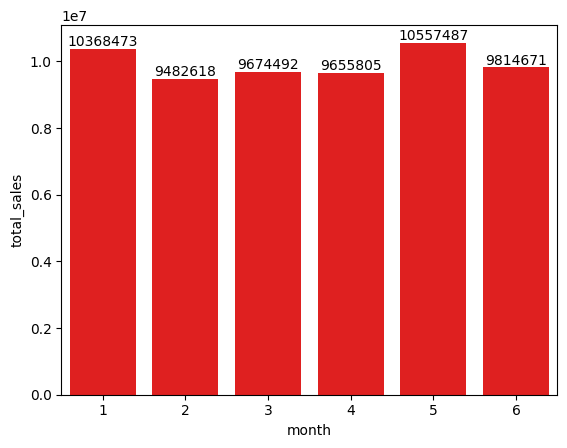

In [311]:
result = result.sort_values(by='month')
sns.barplot(data=result, x='month', y='total_sales', color="red")
for index,value in enumerate(result['total_sales']):
    plt.text(index,value, str(value),ha='center',va='bottom')
plt.xlabel('month')
plt.ylabel('total_sales')
plt.show()

In [312]:
# Question — Monthly sales + previous month comparison
# Only consider Completed transactions.

# Find the monthly sales and calculate the difference from the previous month.

# Expected output:
# month | total_sales | previous_month_sales | sales_difference

In [ ]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result = (
    completed.groupby('month')
    .agg(total_sales =('sales_amount','sum'))
    .sort_values(by='month')
    .reset_index()
)

result['previous_month_sales'] = result['total_sales'].shift(1)
result['sales_difference'] = result['total_sales'] - result['previous_month_sales']
result

# shift(1) = previous row #lag in sql
# shift(-1) = next row #lead in sql

,month,total_sales,previous_month_sales,sales_difference
0,1,10368473,NaN,NaN
1,2,9482618,10368473.0,-885855.0
2,3,9674492,9482618.0,191874.0
3,4,9655805,9674492.0,-18687.0
4,5,10557487,9655805.0,901682.0
5,6,9814671,10557487.0,-742816.0


In [314]:
# Question — Best-performing day of the week

# Consider only Completed transactions.
# Find the performance of each day of the week.

# Expected output:
# day_name | total_transactions | total_sales | avg_transaction_value

# Sort by total_sales from highest to lowest

In [317]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result=(
    completed.groupby('day_name')
    .agg(total_transactions=('transaction_id','count'),
         total_sales=('sales_amount','sum'),
         avg_transaction_value=('sales_amount','mean'))
    .round(2)
    .sort_values(by='total_sales',ascending =False)
    .reset_index()
)

result

,day_name,total_transactions,total_sales,avg_transaction_value
0,Tuesday,176,8946560,50832.73
1,Friday,172,8911237,51809.52
2,Sunday,187,8781775,46961.36
3,Thursday,177,8779214,49600.08
4,Saturday,174,8548408,49128.78
5,Monday,162,8251885,50937.56
6,Wednesday,153,7334467,47937.69


In [318]:
# Question — Monthly active customers

# Find the number of unique customers who made Completed transactions in each month.

# Expected output:
# month | total_customers | total_transactions | total_sales

# Conditions
# Only Completed transactions
# Sort by month from January → December


In [323]:
transaction_df['month_name'] = transaction_df['transaction_date'].dt.month_name()

completed = transaction_df[transaction_df['status']== 'Completed']

result =(
    completed.groupby(['month','month_name'])
    .agg(total_customers=('customer_id','nunique'),
         total_transactions =('transaction_id','count'),
         total_sales = ('sales_amount','sum'))
    .round(2)
    .sort_values(by='month', ascending =True)
    .reset_index()
)
result

,month,month_name,total_customers,total_transactions,total_sales
0,1,January,135,211,10368473
1,2,February,114,187,9482618
2,3,March,136,201,9674492
3,4,April,120,199,9655805
4,5,May,131,203,10557487
5,6,June,131,200,9814671


In [324]:
# Question — Monthly customer spending

# Find the total spending per customer for each month.

# Only consider:
# status = 'Completed'
# Expected output
# month | customer_id | total_spent

# Sort by:
# month → customer_id

In [331]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result = (
    completed.groupby(['month_name','month','customer_id'])
    .agg(total_spent =('sales_amount','sum'))
    .round(2)
    .sort_values(by=['month','customer_id'])
    .reset_index()
)
result

,month_name,month,customer_id,total_spent
0,January,1,C001,167572
1,January,1,C004,25127
2,January,1,C005,10780
3,January,1,C008,56816
4,January,1,C009,92119
...,...,...,...,...
762,June,6,C190,93588
763,June,6,C193,32461
764,June,6,C197,17376
765,June,6,C198,12014


In [332]:
# question — let's combine dates + ranking

# Find the top 2 customers by total spending for each month.

# Conditions:
# Only Completed transactions
# Calculate each customer's total spending within each month
# Keep top 2 per month

# Expected:
# month | customer_id | total_spent | rank

In [ ]:
completed = transaction_df[transaction_df['status'] =='Completed']

result = (
    completed.groupby(['month_name','month','customer_id'])
    .agg(total_spent=('sales_amount','sum'))
    .sort_values(by=['month','customer_id'])
    .reset_index()
)

result['rank'] =(
    result.groupby(['month_name','month'])['total_spent']
    .rank(method='first',ascending=False)
)

result=(
    result[result['rank']<=2]
    [['month_name','month','customer_id','total_spent','rank']]
    .sort_values(by=['month','rank'])
)
result

,month_name,month,customer_id,total_spent,rank
13,January,1,C022,335146,1.0
98,January,1,C148,240324,2.0
186,February,2,C095,283452,1.0
230,February,2,C176,215644,2.0
317,March,3,C102,384601,1.0
300,March,3,C073,240162,2.0
499,April,4,C187,234258,1.0
494,April,4,C179,216746,2.0
546,May,5,C069,353154,1.0
609,May,5,C158,273564,2.0


In [341]:
# Next question — transform() + dates

# Find customers whose monthly spending is greater than the average customer spending for that same month.

# Expected:
# month | customer_id | total_spent | monthly_avg_spending | above_average

# Example:

# January | C001 | 85000 | 62000 | True
# January | C002 | 40000 | 62000 | False
# January | C003 | 71000 | 62000 | True
# February | C001 | 55000 | 58000 | False

# Only Completed transactions.

In [355]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result =(
    completed.groupby(['month_name','month','customer_id'])
    .agg(total_spent=('sales_amount','sum'))
    .sort_values(by=['month','customer_id'])
    .reset_index()   
)

result['monthly_avg_spending'] =(
    result.groupby(['month_name','month'])['total_spent'].transform('mean').round(2)
)

result['above_average'] = (
    result['total_spent'] > result['monthly_avg_spending']
)
result

# transform() gives:

# C001 → 80,000 → 60,000
# C002 → 60,000 → 60,000
# C003 → 40,000 → 60,000

,month_name,month,customer_id,total_spent,monthly_avg_spending,above_average
0,January,1,C001,167572,76803.50,True
1,January,1,C004,25127,76803.50,False
2,January,1,C005,10780,76803.50,False
3,January,1,C008,56816,76803.50,False
4,January,1,C009,92119,76803.50,True
...,...,...,...,...,...,...
762,June,6,C190,93588,74921.15,True
763,June,6,C193,32461,74921.15,False
764,June,6,C197,17376,74921.15,False
765,June,6,C198,12014,74921.15,False


In [358]:
# Ranking Question — Rank cities by monthly sales

# Consider only Completed transactions.

# For each month, calculate the total sales for each city, then rank the cities within each month based on their sales.

# Expected output:
# month | city | total_sales | rank

# Requirements:
# Only Completed
# Keep only the top 2 cities for each month
# Sort by month and rank

In [364]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result = pd.merge(customer_df, completed, on='customer_id',how='inner')

result =(
    result.groupby(['month_name','month','city'])
    .agg(total_sales=('sales_amount','sum'))
    .sort_values(by='month')
    .reset_index()
)

result['rank'] = (
    result.groupby(['month_name','month'])['total_sales']
    .rank(method='first',ascending=False)
)

result=(
    result[result['rank']<=2]
    [['month_name','month','city','total_sales','rank']]
    .sort_values(by=['month','rank'])
)
result

,month_name,month,city,total_sales,rank
5,January,1,Mumbai,2453829,1.0
1,January,1,Hyderabad,2046378,2.0
8,February,2,Hyderabad,2223759,1.0
7,February,2,Mumbai,1941465,2.0
14,March,3,Hyderabad,2020389,1.0
15,March,3,Mumbai,1868326,2.0
22,April,4,Mumbai,2191863,1.0
20,April,4,Chennai,2002430,2.0
29,May,5,Mumbai,2502354,1.0
26,May,5,Chennai,1859147,2.0


In [365]:
#  Pivot Question

# Find total completed sales by:
# Rows: product_category
# Columns: payment_method
# Values: sales_amount
# Aggregation: sum

In [369]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result=(
    pd.pivot_table(
        completed,
        index='product_category', #rows
        columns='payment_method', #colums
        values='sales_amount',
        aggfunc= 'sum',
        fill_value =0
    )
)
result

# fill_value=0 means it converts nan into 0

payment_method,Card,Cash,Net Banking,UPI
product_category,,,,
Accessories,2325336,2081183,3164642,3444182
Electronics,2598125,2333792,3359633,2247035
Fashion,3366280,2531428,3469799,3615070
Furniture,2543355,3458247,3107113,3607003
Grocery,2118391,2937989,3396143,3848800


In [370]:
# Create a pivot table showing average transaction value by:

# Rows: city
# Columns: payment_method
# Values: sales_amount
# Aggregation: mean
# Only Completed transactions
# Replace missing values with 0
# Round to 2 decimals

In [379]:
completed = transaction_df[transaction_df['status'] == "Completed"]

result = pd.merge(customer_df, completed, on='customer_id', how='inner')

result = (
    pd.pivot_table(
        result,
        index ='city',
        columns='payment_method',
        values ='sales_amount',
        aggfunc='mean',
        fill_value=0,
    
    )
)
result= result.round(2)
result

payment_method,Card,Cash,Net Banking,UPI
city,,,,
Bangalore,53151.38,47979.39,52303.80,40800.47
Chennai,43530.12,54849.02,46648.53,50824.12
Delhi,43418.05,48624.23,48459.67,52879.52
Hyderabad,46459.24,47914.81,56794.85,56511.13
Mumbai,41997.02,47194.96,50375.31,53424.77
Pune,50894.74,50951.54,49625.87,51031.14


In [380]:
# Create a pivot table showing:

# Total sales AND number of transactions for each product category and payment method.

# Expected structure:

#                          sales_amount              transaction_id
# payment_method             Card Cash UPI              Card Cash UPI
# product_category
# Electronics                 ...  ...  ...               ...  ...  ...
# Fashion                     ...  ...  ...               ...  ...  ...
# Grocery                     ...  ...  ...               ...  ...  ...

In [ ]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result =(
    pd.pivot_table(
        completed,
        index= 'product_category',
        columns='payment_method',
        values=['sales_amount','transaction_id'],
        aggfunc={
            'sales_amount':'sum',
                'transaction_id':'count'
                },
        fill_value=0
    )
)
result

sales_amount                               transaction_id  \
payment_method           Card     Cash Net Banking      UPI           Card   
product_category                                                             
Accessories           2325336  2081183     3164642  3444182             49   
Electronics           2598125  2333792     3359633  2247035             53   
Fashion               3366280  2531428     3469799  3615070             72   
Furniture             2543355  3458247     3107113  3607003             54   
Grocery               2118391  2937989     3396143  3848800             53   

                                       
payment_method   Cash Net Banking UPI  
product_category                       
Accessories        45          70  63  
Electronics        49          64  47  
Fashion            52          68  66  
Furniture          65          63  77  
Grocery            58          59  74

In [387]:
# question — Pivot + percentage
# Using transaction_df, consider only Completed transactions.

# Create a pivot table showing the total sales by city and product category.
# Then find the percentage contribution of each product category to that city's total sales.

In [400]:
completed = transaction_df[transaction_df['status'] == 'Completed']
result = pd.merge(customer_df, completed, on='customer_id',how='inner')

result=(
    pd.pivot_table(
        result,
        index='city',
        columns='product_category',
        values='sales_amount',
        aggfunc='sum',
        fill_value =0
    )
)
result

product_category,Accessories,Electronics,Fashion,Furniture,Grocery
city,,,,,
Bangalore,1588901,1495338,1620044,1824321,952570
Chennai,1675282,2002601,1800417,2202362,1862216
Delhi,962683,1135418,1874721,2305432,1813079
Hyderabad,2172617,2228121,2676417,2166359,2570591
Mumbai,3145176,1698827,2916512,2816363,2781000
Pune,1470684,1978280,2094466,1400881,2321867


In [ ]:
row_total = result.sum(axis=1)
row_total
#axis =1 for each row add all comukns together
# Easy memory:
# axis=1 → move horizontally → across columns

city
Bangalore     7481174
Chennai       9542878
Delhi         8091333
Hyderabad    11814105
Mumbai       13357878
Pune          9266178
dtype: int64

In [ ]:
# axis=0 → down the rows ⬇️
# result.sum(axis=0)

# Means:

# For each column, add the rows together.

# So:

# Electronics → 40 + 50 + 45 = 135
# Fashion     → 30 + 25 + 35 = 90
# Grocery     → 30 + 25 + 20 = 75

In [402]:
percentage =result.div(row_total , axis=0) *100
percentage= percentage.round(2)
percentage

product_category,Accessories,Electronics,Fashion,Furniture,Grocery
city,,,,,
Bangalore,21.24,19.99,21.65,24.39,12.73
Chennai,17.56,20.99,18.87,23.08,19.51
Delhi,11.90,14.03,23.17,28.49,22.41
Hyderabad,18.39,18.86,22.65,18.34,21.76
Mumbai,23.55,12.72,21.83,21.08,20.82
Pune,15.87,21.35,22.60,15.12,25.06


In [403]:
# Using transaction_df:

# Create a pivot table showing total sales for each payment method within each city.

# Then calculate what percentage of each city's total sales came from each payment method.

# Expected output
#              Card    Cash    UPI
# Mumbai       45%     20%     35%
# Delhi        50%     15%     35%
# Pune         30%     25%     45%

In [405]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result = pd.merge(customer_df, completed, on='customer_id',how='inner')
result =(
    pd.pivot_table(
        result,
        index='city',
        columns= 'payment_method',
        values='sales_amount',
        aggfunc='sum',
        fill_value=0
    )
)
result


payment_method,Card,Cash,Net Banking,UPI
city,,,,
Bangalore,2072904,1823217,1830633,1754420
Chennai,1871795,2742451,2285778,2642854
Delhi,1736722,1701848,2326064,2326699
Hyderabad,2926932,2539485,3691665,2656023
Mumbai,2561818,2548528,4080400,4167132
Pune,1781316,1987110,2282790,3214962


In [408]:
row_total =result.sum(axis=1)
percentage = result.div(row_total , axis=0) *100
percentage= percentage.round(2)
percentage

payment_method,Card,Cash,Net Banking,UPI
city,,,,
Bangalore,27.71,24.37,24.47,23.45
Chennai,19.61,28.74,23.95,27.69
Delhi,21.46,21.03,28.75,28.76
Hyderabad,24.77,21.50,31.25,22.48
Mumbai,19.18,19.08,30.55,31.20
Pune,19.22,21.44,24.64,34.70


In [409]:
# Pivot Question — slightly harder

# Using transaction_df, only Completed transactions:

# Create a pivot table showing for each city and product category:

# Total sales
# Number of transactions
# Average transaction value

In [419]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result = pd.merge(customer_df, completed, on='customer_id',how='inner')
result =(
    pd.pivot_table(
        result,
        index=['city','product_category'],
        values = ['sales_amount','transaction_id'],
        aggfunc={
            'sales_amount':['sum','mean'],
            'transaction_id':'count'
        },
        fill_value=0
    )
).round(2)
result

sales_amount          transaction_id
                                   mean      sum          count
city      product_category                                     
Bangalore Accessories          49653.16  1588901             32
          Electronics          49844.60  1495338             30
          Fashion              54001.47  1620044             30
          Furniture            44495.63  1824321             41
          Grocery              43298.64   952570             22
Chennai   Accessories          50766.12  1675282             33
          Electronics          47680.98  2002601             42
          Fashion              46164.54  1800417             39
          Furniture            47877.43  2202362             46
          Grocery              54771.06  1862216             34
Delhi     Accessories          38507.32   962683             25
          Electronics          43669.92  1135418             26
          Fashion              46868.02  1874721             40
          Furniture            56230.05  2305432             41
          Grocery              51802.26  1813079             35
Hyderabad Accessories          50525.98  2172617             43
          Electronics          51816.77  2228121             43
          Fashion              55758.69  2676417             48
          Furniture            52838.02  2166359             41
          Grocery              48501.72  2570591             53
Mumbai    Accessories          49143.38  3145176             64
          Electronics          47189.64  1698827             36
          Fashion              48608.53  2916512             60
          Furniture            49409.88  2816363             57
          Grocery              48789.47  2781000             57
Pune      Accessories          49022.80  1470684             30
          Electronics          54952.22  1978280             36
          Fashion              51084.54  2094466             41
          Furniture            42450.94  1400881             33
          Grocery              53996.91  2321867             43

In [420]:
# Question  — Customer spending + ranking
# Consider only Completed transactions.

# Find the top 3 customers by total spending within each customer segment.
# Expected output
# customer_id | customer_name | customer_segment | total_spent | rank

In [433]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result = pd.merge(customer_df, completed, on='customer_id', how='left')

result = (
    result.groupby(['customer_segment', 'customer_id','customer_name'])
    .agg(total_spent = ('sales_amount','sum'))
    .reset_index()
)

result['rank'] = (
    result.groupby('customer_segment')['total_spent']
    .rank(method='first', ascending=False)
)

result = (
    result[result['rank'] <= 3]
    [['customer_segment','customer_id','customer_name','total_spent','rank']]
    .sort_values(by=['customer_segment','rank'])
)
result

,customer_segment,customer_id,customer_name,total_spent,rank
58,New,C148,Customer_148,716424,1.0
2,New,C009,Customer_9,577009,2.0
19,New,C052,Customer_52,554292,3.0
106,Premium,C096,Customer_96,669504,1.0
127,Premium,C152,Customer_152,570156,2.0
123,Premium,C145,Customer_145,566460,3.0
173,Regular,C102,Customer_102,751310,1.0
170,Regular,C095,Customer_95,747979,2.0
190,Regular,C176,Customer_176,586709,3.0


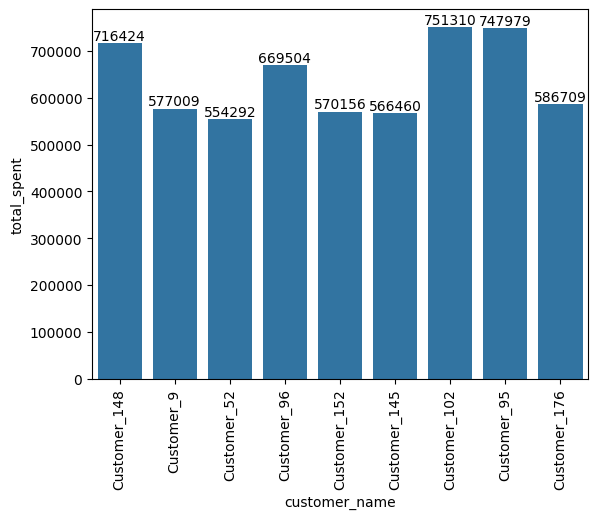

In [440]:
sns.barplot(data = result, x='customer_name', y='total_spent')
for index,value in enumerate(result['total_spent']):
    plt.text(index, value, str(value), ha='center',va='bottom')
plt.xticks(rotation=90)
plt.show()

In [425]:
# Question — Monthly category analysis + percentage


# Consider only Completed transactions.

# Create a pivot table showing total sales for each product category by month.

# Then calculate the percentage contribution of each category to that month's total sales.

# Expected output
#              Electronics  Fashion  Grocery
# January          35.5%      40.2%    24.3%
# February         42.1%      31.5%    26.4%
# March            ...

In [429]:
completed = transaction_df[transaction_df['status'] == 'Completed']

result =(
    pd.pivot_table(
        completed,
        index= ['month','month_name'],
        columns = 'product_category',
        values = 'sales_amount',
        aggfunc='sum',
        fill_value =0
    )
)
result

,product_category,Accessories,Electronics,Fashion,Furniture,Grocery
month,month_name,,,,,
1,January,1980872,1292832,2367132,1876112,2851525
2,February,2015510,1743748,1799978,2307822,1615560
3,March,2072899,1896606,2220590,1954904,1529493
4,April,1891470,1429477,2163258,1914443,2257157
5,May,1800491,2281084,2290111,2278420,1907381
6,June,1254101,1894838,2141508,2384017,2140207


In [430]:
row_totals = result.sum(axis=1)
percent = result.div(row_totals, axis =0) *100
percent = percent.round(2)
percent

,product_category,Accessories,Electronics,Fashion,Furniture,Grocery
month,month_name,,,,,
1,January,19.10,12.47,22.83,18.09,27.50
2,February,21.25,18.39,18.98,24.34,17.04
3,March,21.43,19.60,22.95,20.21,15.81
4,April,19.59,14.80,22.40,19.83,23.38
5,May,17.05,21.61,21.69,21.58,18.07
6,June,12.78,19.31,21.82,24.29,21.81
